# Deforestación Perú — Generar máscaras (labels) desde el GeoJSON

**Proyecto final MIA-07** — Detección de deforestación con U-Net.

**No hace falta etiquetar a mano.** Los polígonos SERFOR del GeoJSON YA son las etiquetas. Aquí los **rasterizamos** sobre la grilla de cada imagen Sentinel-2 descargada (notebook 02) → una **máscara binaria** alineada:

- `1` = pixel deforestado (dentro de un polígono)
- `0` = no deforestado

Cada par **(imagen 4-band, máscara)** es un ejemplo de entrenamiento para la U-Net.

```
polígonos GeoJSON  +  imagen Sentinel-2 (transform, CRS, tamaño)
         |
   rasterize() -> pixeles dentro del polígono = 1
         |
   máscara binaria  =  label alineado a la imagen
```

## 1. Almacenamiento (Drive en Colab, o local)

In [1]:
from pathlib import Path

try:
    from google.colab import drive
    drive.mount("/content/drive")
    BASE_DIR = Path("/content/drive/MyDrive/deforestacion-peru")
except ImportError:
    BASE_DIR = Path(".")

DATA_DIR  = BASE_DIR / "data"
# Dataset de detección de cambio (before/after) del notebook 02.
IMG_DIR   = DATA_DIR / "sentinel_cd"        # imágenes A/B del notebook 02
MASK_DIR  = DATA_DIR / "masks_cd"           # salida: máscaras
MASK_DIR.mkdir(parents=True, exist_ok=True)
MANIFEST_PATH = DATA_DIR / "sentinel_manifest_cd.json"

# Resultados de la curación web (carpeta config-fixed/ en la raíz del Drive).
# Si los pusiste en otra carpeta, cambia CONFIG_DIR. Opcionales: sin archivo,
# se usan todas las escenas ok y solo los polígonos SERFOR.
CONFIG_DIR = BASE_DIR / "config-fixed"
KEEP_PATH = CONFIG_DIR / "seleccion_keep_cd.json"     # escenas a mantener (CD)
EXCL_PATH = CONFIG_DIR / "objectid_excluidos.json"    # polígonos inválidos (OBJECTID)
print("Imágenes:", IMG_DIR, "| Máscaras:", MASK_DIR, "| Config:", CONFIG_DIR)

Mounted at /content/drive
Imágenes: /content/drive/MyDrive/deforestacion-peru/data/sentinel_cd | Máscaras: /content/drive/MyDrive/deforestacion-peru/data/masks_cd | Config: /content/drive/MyDrive/deforestacion-peru/config-fixed


## 2. Cargar polígonos y manifest

In [2]:
import json
import pandas as pd
import geopandas as gpd

gdf = gpd.read_file(DATA_DIR / "deforestacion.geojson")
# fechas del evento de cada polígono (para el filtro temporal de la máscara)
gdf["FESATA_dt"] = pd.to_datetime(gdf["FESATA"], errors="coerce")
gdf["FESATB_dt"] = pd.to_datetime(gdf["FESATB"], errors="coerce")

manifest = json.loads(MANIFEST_PATH.read_text())
oks = [r for r in manifest.values() if r.get("status") == "ok"]
n_poly0, n_oks0 = len(gdf), len(oks)

# 1) Excluir polígonos marcados como inválidos en el curador (reforestados /
#    mal etiquetados). objectid_excluidos.json = lista de OBJECTID.
excluidos = set()
if EXCL_PATH.exists():
    excluidos = {int(x) for x in json.loads(EXCL_PATH.read_text())}
    gdf = gdf[~gdf["OBJECTID"].astype(int).isin(excluidos)].copy()

# 2) Quedarnos solo con las escenas marcadas "keep". El export puede ser
#    [{"row_id":...}] o una lista simple de row_id; soportamos ambos.
keep_ids = None
if KEEP_PATH.exists():
    keep = json.loads(KEEP_PATH.read_text())
    keep_ids = {str(k["row_id"]) if isinstance(k, dict) else str(k) for k in keep}
    oks = [r for r in oks if str(r["row_id"]) in keep_ids]

# 3) Anotaciones manuales del curador (curador-cd: ✏/varita). Se SUMAN a los
#    polígonos SERFOR por tile (row_id). EPSG:4326, props row_id/objectid.
ANNOT_PATH = CONFIG_DIR / "anotaciones_cd.geojson"
annot_by_rid = {}
if ANNOT_PATH.exists():
    ag = gpd.read_file(ANNOT_PATH)
    for _, rr in ag.iterrows():
        annot_by_rid.setdefault(str(rr["row_id"]), []).append(rr.geometry)
    print(f"Anotaciones manuales: {len(ag)} polígonos en {len(annot_by_rid)} tiles (se suman a SERFOR)")
else:
    print("Sin anotaciones_cd.geojson (solo SERFOR)")

print(f"Polígonos: {len(gdf):,}/{n_poly0:,} (excluidos {len(excluidos)})")
print(f"Imágenes ok: {len(oks)}/{n_oks0}" + ("" if keep_ids is None else " (filtradas por keep)"))

Sin anotaciones_cd.geojson (solo SERFOR)
Polígonos: 9,910/9,910 (excluidos 0)
Imágenes ok: 1039/1039


## 3. Rasterizar máscaras

Para cada imagen tomamos **todos** los polígonos que caen en su recorte (un tile puede tener varios), los reproyectamos al CRS de la imagen y los quemamos en una máscara del mismo tamaño exacto.

Si curaste en el sitio web, las máscaras ya respetan eso: los polígonos en `objectid_excluidos.json` (reforestados / mal etiquetados) **no** se queman, y solo se procesan las escenas marcadas *keep*.

In [3]:
import numpy as np
import pandas as pd
import rasterio
from rasterio.features import rasterize
from rasterio.warp import transform_bounds
from shapely.geometry import box
from tqdm.auto import tqdm

def make_mask(rec, gdf):
    """Máscara binaria del CAMBIO del par, alineada a la imagen 'después'.
    Quema: (a) polígonos SERFOR cuyo evento [FESATA,FESATB] cae dentro de la
    ventana del par [fecha_antes, fecha_después] (evita marcar clareo viejo), y
    (b) los polígonos dibujados a mano para ese tile (annot_by_rid), que se SUMAN."""
    with rasterio.open(rec["path"]) as src:
        H, W = src.height, src.width
        transform, crs, bounds = src.transform, src.crs, src.bounds

    # candidatos SERFOR que tocan el tile (filtro barato lon/lat antes de reproyectar)
    lon_min, lat_min, lon_max, lat_max = transform_bounds(crs, "EPSG:4326", *bounds)
    cand = gdf[gdf.intersects(box(lon_min, lat_min, lon_max, lat_max))]

    # filtro temporal: solo el cambio visible en este par (en pie en 'antes',
    # clareado en 'después'). Polígonos sin fecha o de otro período -> fuera.
    a_date = pd.to_datetime(rec["antes"]["datetime"])
    b_date = pd.to_datetime(rec["despues"]["datetime"])
    cand = cand[(cand["FESATA_dt"] >= a_date) & (cand["FESATB_dt"] <= b_date)]

    geoms = list(cand.to_crs(crs).geometry) if len(cand) else []

    # SUMA: polígonos dibujados a mano para este tile (EPSG:4326 -> CRS imagen)
    extra = annot_by_rid.get(str(rec["row_id"]), [])
    if extra:
        ex = gpd.GeoSeries(extra, crs="EPSG:4326").to_crs(crs)
        geoms += [g for g in ex.geometry if g is not None and not g.is_empty]

    if not geoms:
        mask = np.zeros((H, W), dtype="uint8")
        npoly = 0
    else:
        mask = rasterize([(g, 1) for g in geoms],
                         out_shape=(H, W), transform=transform,
                         fill=0, dtype="uint8", all_touched=False)
        npoly = len(geoms)

    out_path = MASK_DIR / f"mask_{rec['row_id']}.tif"
    prof = dict(driver="GTiff", height=H, width=W, count=1, dtype="uint8",
                crs=crs, transform=transform, compress="deflate")
    with rasterio.open(out_path, "w", **prof) as dst:
        dst.write(mask, 1)
    return out_path, float(mask.mean()), npoly

n_done = 0
frac_total = 0.0
for rec in tqdm(oks, desc="Máscaras"):
    if not Path(rec["path"]).exists():
        continue
    _, frac, npoly = make_mask(rec, gdf)
    frac_total += frac
    n_done += 1

print(f"\nMáscaras generadas: {n_done}")
if n_done:
    print(f"% deforestado promedio por tile: {100*frac_total/n_done:.1f}%")
print(f"Máscaras en disco: {len(list(MASK_DIR.glob('mask_*.tif')))}")

Máscaras:   0%|          | 0/1039 [00:00<?, ?it/s]


Máscaras generadas: 1039
% deforestado promedio por tile: 2.8%
Máscaras en disco: 1039


## 4. Verificación: imagen RGB + máscara + overlay

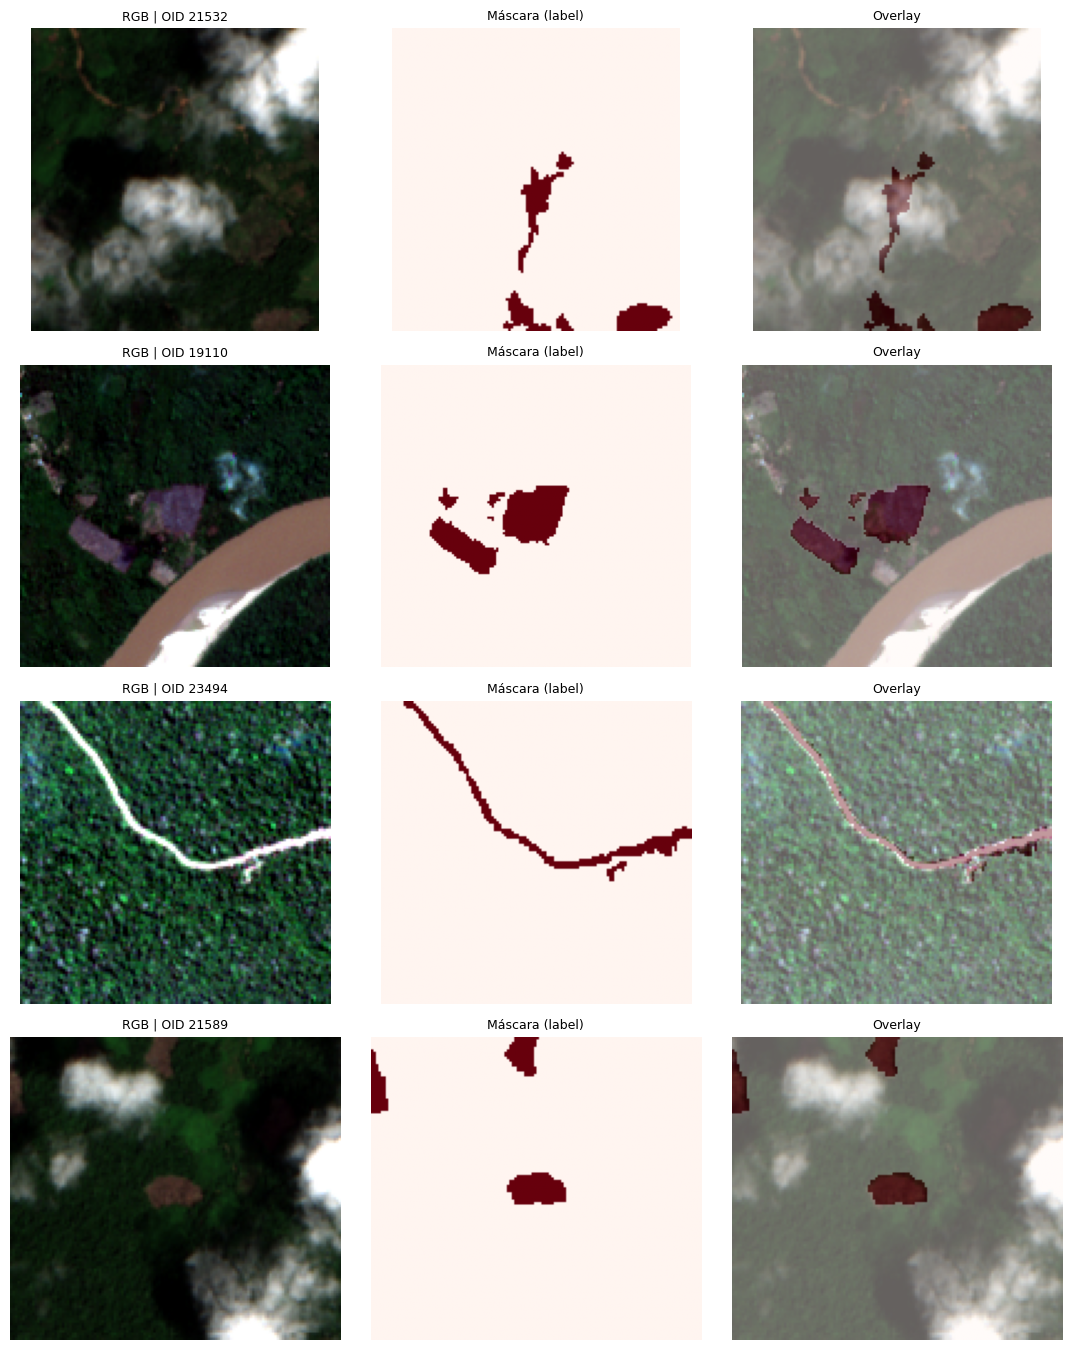

In [4]:
import matplotlib.pyplot as plt

def stretch(a, lo=2, hi=98):
    a = a.astype("float32"); pl, ph = np.percentile(a, [lo, hi])
    return np.clip((a - pl) / (ph - pl + 1e-6), 0, 1)

sample = [r for r in oks if Path(r["path"]).exists()][:4]
fig, axes = plt.subplots(len(sample), 3, figsize=(11, 3.4 * len(sample)))
axes = np.atleast_2d(axes)
for row, rec in zip(axes, sample):
    with rasterio.open(rec["path"]) as src:
        arr = src.read().astype("float32")
    with rasterio.open(MASK_DIR / f"mask_{rec['row_id']}.tif") as src:
        mask = src.read(1)
    rgb = np.dstack([stretch(arr[i]) for i in range(3)])
    row[0].imshow(rgb); row[0].set_title(f"RGB | OID {rec['objectid']}", fontsize=9)
    row[1].imshow(mask, cmap="Reds", vmin=0, vmax=1); row[1].set_title("Máscara (label)", fontsize=9)
    row[2].imshow(rgb); row[2].imshow(mask, cmap="Reds", alpha=0.4, vmin=0, vmax=1); row[2].set_title("Overlay", fontsize=9)
    for a in row: a.axis("off")
plt.tight_layout()
plt.savefig(str(DATA_DIR / "masks_muestra.png"), dpi=110, bbox_inches="tight")
plt.show()

## 5. Próximos pasos

Ya tienes pares **(imagen 4-band, máscara binaria)** alineados — el dataset crudo para la U-Net.

- `04_dataset_parches.ipynb`: cortar imágenes y máscaras en parches 256×256, normalizar bandas, split train/val/test → dataset PyTorch.
- `05_modelo_unet.ipynb`: entrenar U-Net (entrada 4 canales R,G,B,NIR → salida 1 canal sigmoide). Loss = BCE + Dice. Copia los datos de Drive a `/content` antes de entrenar.
- `06_evaluacion.ipynb`: IoU, F1, Dice sobre el set de test.

> Nota sobre desbalance: la deforestación es una fracción chica de cada tile (~10%). En el entrenamiento usa **Dice loss** o **BCE con peso a la clase positiva** para que el modelo no aprenda a predecir solo "0".